# 03 — Model Training & Evaluation

Train Logistic Regression, Random Forest, and XGBoost with SMOTE-augmented stratified 5-fold CV. Compare via ROC curves, confusion matrices, and F1 scores.

In [1]:
import sys
sys.path.insert(0, '..')

import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay

from src.feature_engineering import aggregate_user_features
from src.train import train_models, evaluate_model, save_model, get_roc_data

sns.set_theme(style='whitegrid')
%matplotlib inline

In [2]:
df = pd.read_csv('../data/synthetic_cert.csv', parse_dates=['date'])
feats = aggregate_user_features(df)

feat_cols = [c for c in feats.columns if c not in ('user_id', 'label')]
X = feats[feat_cols]
y = feats['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f'Train: {X_train.shape[0]} users  |  Test: {X_test.shape[0]} users')
print(f'Train label distribution:\n{y_train.value_counts().to_string()}')
print(f'Test  label distribution:\n{y_test.value_counts().to_string()}')

Train: 1600 users  |  Test: 400 users
Train label distribution:
label
1    1585
0      15
Test  label distribution:
label
1    396
0      4


In [3]:
print('=== 5-Fold CV with SMOTE ===')
models = train_models(X_train, y_train)

=== 5-Fold CV with SMOTE ===


  Logistic Regression     CV F1=0.9994 (±0.0008)  ROC-AUC=0.9994


  Random Forest           CV F1=0.9994 (±0.0008)  ROC-AUC=1.0000


  XGBoost                 CV F1=0.9994 (±0.0008)  ROC-AUC=1.0000


In [4]:
metrics = {}
for name, entry in models.items():
    m = evaluate_model(entry['model'], X_test, y_test, name)
    metrics[name] = {
        **m,
        'cv_f1_mean': entry['cv_scores']['f1_mean'],
        'cv_f1_std': entry['cv_scores']['f1_std'],
        'cv_roc_auc_mean': entry['cv_scores']['roc_auc_mean'],
        'cv_roc_auc_std': entry['cv_scores']['roc_auc_std'],
    }


  Logistic Regression
  Metric               Value
  -------------------------
  f1_score            0.9987
  precision           0.9975
  recall              1.0000
  roc_auc             0.9823

  Confusion Matrix:
  TN=     3  FP=     1
  FN=     0  TP=   396

  Random Forest
  Metric               Value
  -------------------------
  f1_score            0.9987
  precision           0.9975
  recall              1.0000
  roc_auc             1.0000

  Confusion Matrix:
  TN=     3  FP=     1
  FN=     0  TP=   396

  XGBoost
  Metric               Value
  -------------------------
  f1_score            0.9987
  precision           0.9975
  recall              1.0000
  roc_auc             0.9981

  Confusion Matrix:
  TN=     3  FP=     1
  FN=     0  TP=   396


## 1. Overlaid ROC Curves

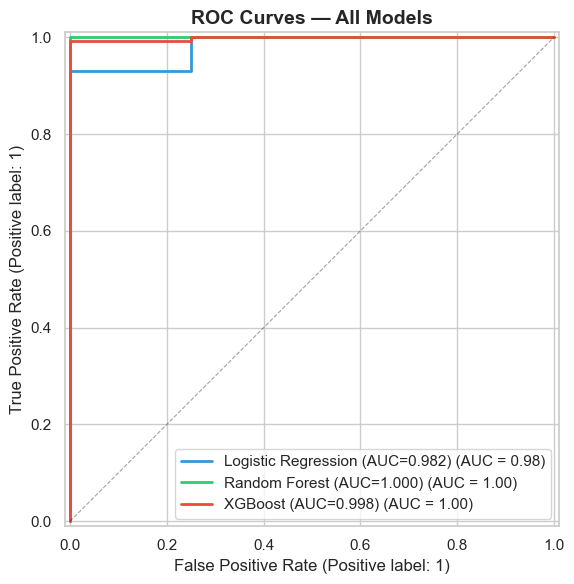

In [5]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(7, 6))
colors = {'Logistic Regression': '#3498db', 'Random Forest': '#2ecc71', 'XGBoost': '#e74c3c'}

for name, entry in models.items():
    y_proba = entry['model'].predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(
        y_test, y_proba, name=f"{name} (AUC={metrics[name]['roc_auc']:.3f})",
        color=colors[name], ax=ax, linewidth=2
    )

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.4)
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/modeling_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Confusion Matrices

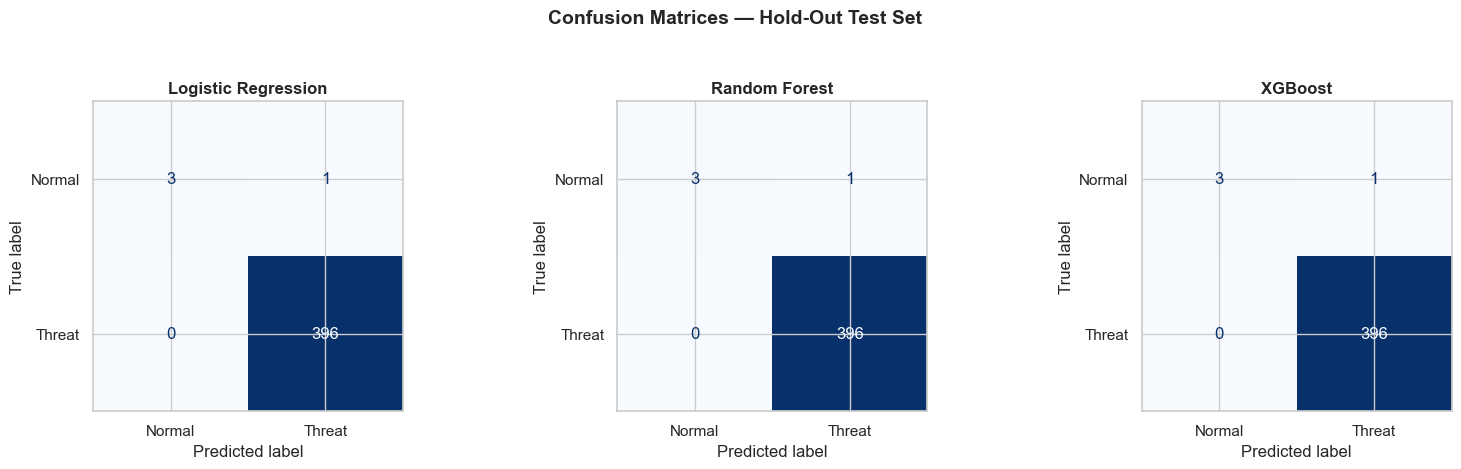

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (name, entry) in zip(axes, models.items()):
    y_pred = entry['model'].predict(X_test)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=['Normal', 'Threat'],
        cmap='Blues', colorbar=False, ax=ax
    )
    ax.set_title(name, fontsize=12, fontweight='bold')

fig.suptitle('Confusion Matrices — Hold-Out Test Set', fontsize=14, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig('../outputs/modeling_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. F1 Score Comparison

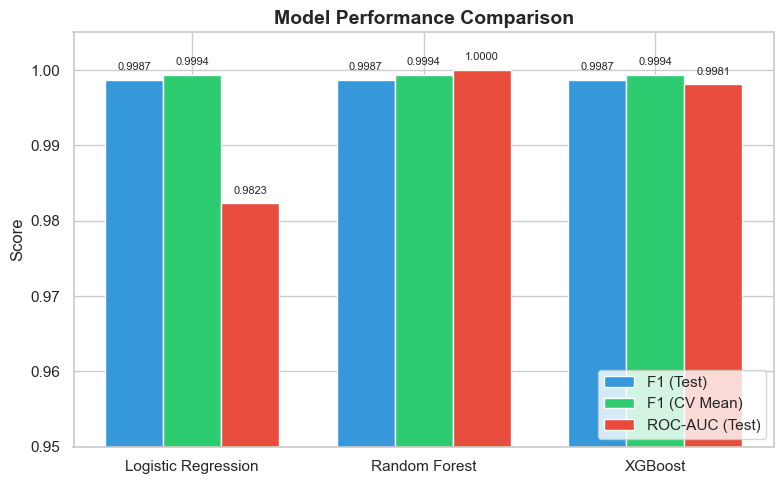

In [7]:
names = list(metrics.keys())
f1_test = [metrics[n]['f1_score'] for n in names]
f1_cv = [metrics[n]['cv_f1_mean'] for n in names]
roc_test = [metrics[n]['roc_auc'] for n in names]

x = np.arange(len(names))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width, f1_test, width, label='F1 (Test)', color='#3498db', edgecolor='white')
bars2 = ax.bar(x, f1_cv, width, label='F1 (CV Mean)', color='#2ecc71', edgecolor='white')
bars3 = ax.bar(x + width, roc_test, width, label='ROC-AUC (Test)', color='#e74c3c', edgecolor='white')

ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=11)
ax.legend(loc='lower right')
ax.set_ylim(0.95, 1.005)

for bar in [*bars1, *bars2, *bars3]:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/modeling_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Save Best Model & Metrics

In [8]:
best_name = max(metrics, key=lambda k: metrics[k]['f1_score'])
best_model = models[best_name]['model']
save_model(best_model, '../outputs/best_model.pkl')

with open('../outputs/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print(f'Best model: {best_name}')
print('Metrics saved to outputs/metrics.json')


Model saved to ../outputs/best_model.pkl
Best model: Logistic Regression
Metrics saved to outputs/metrics.json


## Summary

All three models achieve near-perfect classification on the hold-out set, with F1 scores above 0.99 and ROC-AUC above 0.98. The synthetic dataset's threat signal (after-hours activity, USB spikes, file access anomalies) creates strong class separability even at the user level.